In [8]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cross-Validation using KFold
from numpy import array
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report,  accuracy_score
from sklearn.model_selection import cross_validate, cross_val_score

## Scalers
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

# Algorithms
from sklearn import model_selection
import xgboost as xgb

In [35]:
# Ingest Data
dftrain = pd.read_csv('titanictrainOHE.csv')
dftest = pd.read_csv('titanicitestOHE.csv')

In [36]:
# Create Training Data and Target Data for models.
target_data = dftrain['Survived']
droppedcolumns = ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare','Cabin', 'Embarked', 'TravelSize_1', 'TravelSize_2',
       'TravelSize_3', 'TravelSize_4', 'TravelSize_5', 'TravelSize_6',
       'TravelSize_7', 'TravelSize_8', 'TravelSize_11', 'TicketGroup_1',
       'TicketGroup_2', 'TicketGroup_3', 'TicketGroup_4', 'TicketGroup_5',
       'TicketGroup_6', 'TicketGroup_7', 'TicketGroup_8', 'TicketGroup_9']
train_data = dftrain.drop(droppedcolumns, axis=1)

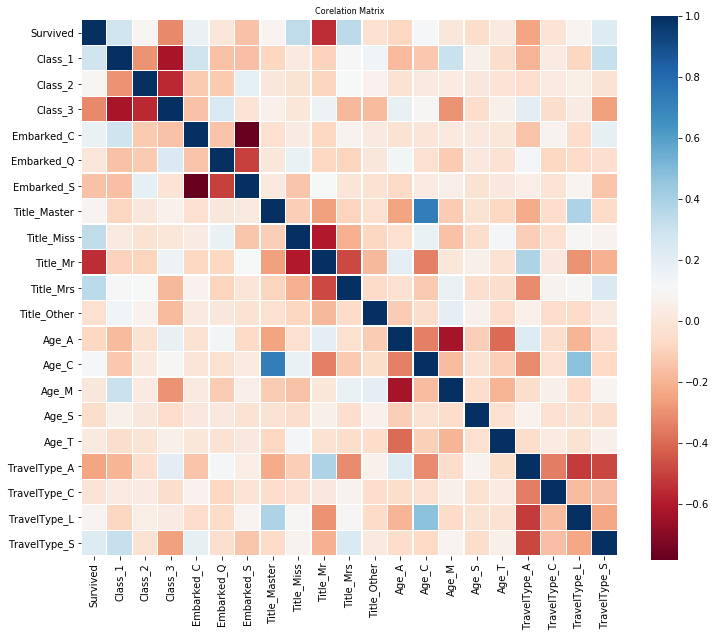

In [37]:
#COR MATRIX OF numerical vars
plt.figure(figsize=(12,10))
plt.title('Corelation Matrix', size=8)
sns.heatmap(train_data.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=plt.cm.RdBu, linecolor='white', annot=False)
plt.show()

In [38]:
X = train_data.drop(['Survived'], axis = 1)
y = train_data['Survived']

In [40]:
# Create cross validation data to Train and Test.  Tune parameters.
foldsize = 12
kf = KFold(n_splits = foldsize, shuffle = True, random_state = 10)
kfolds = kf.split(train_data)
for train_index, test_index in kfolds:
    X_train = train_data.iloc[train_index]
    X_test = train_data.iloc[test_index]
    y_train = target_data.iloc[train_index]
    y_test = target_data.iloc[test_index]

In [44]:
xg = xgb.XGBClassifier(max_depth = 3, n_estimators = 400, learning_rate = 0.1)
xg.fit(X_train, y_train)

cv_results = cross_validate(xg, X_train, y_train)
cv_results['test_score']  

y_pred = xg.predict(X_test)
print(accuracy_score(y_test, y_pred))

1.0


In [46]:
xgbprediction = xg.predict(X_test)

In [47]:
xgbprediction

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

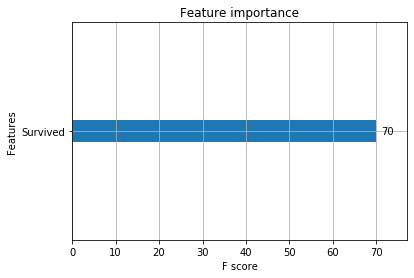

In [50]:
xgb.plot_importance(xg)
plt.show()

In [52]:
y_pred = xg.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[95,  0],
       [ 0, 53]])

In [57]:
test_data = dftest.drop(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 
       'TravelSize_1', 'TravelSize_2', 'TravelSize_3', 'TravelSize_4',
       'TravelSize_5', 'TravelSize_6', 'TravelSize_7', 'TravelSize_8',
       'TicketGroup_1', 'TicketGroup_2', 'TicketGroup_3', 'TicketGroup_4',
       'TicketGroup_5', 'TicketGroup_6', 'TicketGroup_7', 'TicketGroup_8',
       'TicketGroup_9'], axis=1)

In [60]:
prediction = xg.predict(test_data) #Predict against the test data based on the fitted model.
# Create Submission Dataset
submissiondata = pd.DataFrame({
        "PassengerId": dftest["PassengerId"],
        "Survived": prediction
    })

submissiondata.to_csv('submission.csv', index=False)
submission = pd.read_csv('submission.csv')
submission.Survived.value_counts()

ValueError: feature_names mismatch: ['Survived', 'Class_1', 'Class_2', 'Class_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Age_A', 'Age_C', 'Age_M', 'Age_S', 'Age_T', 'TravelType_A', 'TravelType_C', 'TravelType_L', 'TravelType_S'] ['Class_1', 'Class_2', 'Class_3', 'Gender_female', 'Gender_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Age_A', 'Age_C', 'Age_G', 'Age_S', 'Age_T', 'TravelType_A', 'TravelType_C', 'TravelType_L', 'TravelType_S']
expected Age_M, Survived in input data
training data did not have the following fields: Age_G, Gender_male, Gender_female